<center> <h2><b>3 Representation Learning</b></h2> </center>

In [165]:
import importlib
import sys
sys.path.append("../..")  # Ensure the parent directory is in the path

import visualization.data_exploration_plots
import data_preprocessing.data_preprocessing
import models.classic_ml.classic_ml_models
import models.lstm_rnn.lstm_rnn
import models.self_supervised_transformer.self_supervised_transformer

# Reload the module to reflect changes
importlib.reload(visualization.data_exploration_plots)
importlib.reload(data_preprocessing.data_preprocessing)
importlib.reload(models.classic_ml.classic_ml_models)
importlib.reload(models.lstm_rnn.lstm_rnn)
importlib.reload(models.self_supervised_transformer)

from data_preprocessing.data_cleaning import *
from models.classic_ml.classic_ml_models import *
from utils.data_loader import load_and_clean_data

import torch

from models.self_supervised_transformer.self_supervised_transformer import *

from models.lstm_rnn.lstm_rnn import preprocess_for_lstm, build_lstm_model
import tensorflow as tf

from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
from keras.utils import set_random_seed
from keras.src.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
set_random_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.mps.is_available() else
                      "cpu")
print(f"Using : {device}")

Using : mps


# Prepare Data

In [166]:
x_paths = ['set-a.parquet', 'set-b.parquet', 'set-c.parquet']
y_paths = ['outcomes-a.parquet', 'outcomes-b.parquet', 'outcomes-c.parquet']

X_train, X_valid, X_test, y_train, y_valid, y_test = load_and_clean_data(x_paths, y_paths, clean_data)

In [167]:
X_train.head(3)

,recordid,time,ALP,ALT,AST,Age,Albumin,BUN,Bilirubin,Cholesterol,...,RespRate,SaO2,SysABP,Temp,TroponinI,TroponinT,Urine,WBC,Weight,pH
0,132539,00:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,132539,01:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,19.0,NaN,NaN,35.6,NaN,NaN,60.0,NaN,NaN,NaN
2,132539,02:00,NaN,NaN,NaN,54,NaN,NaN,NaN,NaN,...,18.0,NaN,NaN,NaN,NaN,NaN,30.0,NaN,NaN,NaN


## Q3.1 Pretraining and Linear Probes

### Pretrain Transformer

In [168]:
X_train_lstm, X_valid_lstm, X_test_lstm = preprocess_for_lstm(X_train, X_valid, X_test)

In [169]:
X_train_lstm = torch.tensor(X_train_lstm, dtype=torch.float32).to(device)
X_valid_lstm = torch.tensor(X_valid_lstm, dtype=torch.float32).to(device)
X_test_lstm = torch.tensor(X_test_lstm, dtype=torch.float32).to(device)

In [170]:
model = ContrastiveICUTransformer().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = InfoNCELoss()

# Use X_train_lstm as the dataset
dataset = AugmentedDataset(X_train_lstm, augment_fn)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Train the model
train_contrastive_model(model, dataloader, optimizer, loss_fn, epochs=15)

/Users/tnorlha/miniconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/15, Loss: 1.3424579725265502
Epoch 2/15, Loss: 1.259581518650055
Epoch 3/15, Loss: 1.2588976140022279
Epoch 4/15, Loss: 1.2494638195037842
Epoch 5/15, Loss: 1.24650354719162
Epoch 6/15, Loss: 1.2345774898529052
Epoch 7/15, Loss: 1.2354455561637878
Epoch 8/15, Loss: 1.2287991285324096
Epoch 9/15, Loss: 1.221460751056671
Epoch 10/15, Loss: 1.2201318225860596
Epoch 11/15, Loss: 1.2115024633407592
Epoch 12/15, Loss: 1.2112666945457458
Epoch 13/15, Loss: 1.211711447238922
Epoch 14/15, Loss: 1.211847638130188
Epoch 15/15, Loss: 1.210528863430023


### Freeze weights + Compute a single embedding vector for each patient + train a logistic regression

In [171]:
model.eval()

X_train_embeddings = model(X_train_lstm.to(device)).cpu().detach().numpy()
X_valid_embeddings = model(X_valid_lstm.to(device)).cpu().detach().numpy()
X_test_embeddings = model(X_test_lstm.to(device)).cpu().detach().numpy()

In [172]:
results_lr = train_and_evaluate_model('lr', X_train_embeddings, X_valid_embeddings, X_test_embeddings, y_train, y_valid, y_test)

In [173]:
results_lr

{'validation': {'auroc': 0.7453190149052825, 'auprc': 0.3142473117172541},
 'test': {'auroc': 0.7474605498617213, 'auprc': 0.3293492593550456}}

## Q3.2 Simulate label scarcity

In [174]:
# Define patient sample sizes
sample_sizes = [100, 500, 1000, 4000]

- Train three different supervised (as in Q2.x) models with the same (or as similar as
possible) architecture as your pretrained network, but only use 100, 500, and 1000
patients from the training set and report your full test set performance.


--> see notebook 2 for the results

- Train three linear probes (as in Q3.1 step 2) using only 100, 500, 1000 labelled
patients and report the full test set C performance.

In [175]:
# Store results
results_lr = {}

for num_patients in sample_sizes:
    # Select a random subset of patients from X_train_compressed
    indices = np.random.choice(len(X_train_embeddings), num_patients, replace=False)
    X_train_subset = X_train_embeddings[indices]
    y_train_subset = y_train[indices]

    # Train and evaluate the model
    results_lr[num_patients] = train_and_evaluate_model('lr', X_train_subset, X_valid_embeddings, X_test_embeddings, y_train_subset, y_valid, y_test)

# Print results
for num, res in results_lr.items():
    print(f"Train Size: {num}")
    print(f"  Validation AUROC: {res['validation']['auroc']:.4f}, AUPRC: {res['validation']['auprc']:.4f}")
    print(f"  Test AUROC: {res['test']['auroc']:.4f}, AUPRC: {res['test']['auprc']:.4f}")
    print("-" * 50)

Train Size: 100
  Validation AUROC: 0.6517, AUPRC: 0.2274
  Test AUROC: 0.6488, AUPRC: 0.2263
--------------------------------------------------
Train Size: 500
  Validation AUROC: 0.7127, AUPRC: 0.2772
  Test AUROC: 0.7002, AUPRC: 0.2889
--------------------------------------------------
Train Size: 1000
  Validation AUROC: 0.7266, AUPRC: 0.3074
  Test AUROC: 0.7307, AUPRC: 0.3113
--------------------------------------------------
Train Size: 4000
  Validation AUROC: 0.7453, AUPRC: 0.3142
  Test AUROC: 0.7475, AUPRC: 0.3294
--------------------------------------------------


## Q.3.3 Visualising Learned Representations

Visualize your learned representations through a dimensionality reduction technique such as
t-SNE7 or UMAP8 (2 Pt).

Are data points with different labels distributed identically? (1 pt)


Use a quantitative clustering metric to assess the quality of your dimensionality reduction
w.r.t. target class labels (1 pt).

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4000 samples in 0.000s...
[t-SNE] Computed neighbors for 4000 samples in 0.062s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4000
[t-SNE] Computed conditional probabilities for sample 2000 / 4000
[t-SNE] Computed conditional probabilities for sample 3000 / 4000
[t-SNE] Computed conditional probabilities for sample 4000 / 4000
[t-SNE] Mean sigma: 0.527514
[t-SNE] KL divergence after 250 iterations with early exaggeration: 82.973412
[t-SNE] KL divergence after 1000 iterations: 1.588724


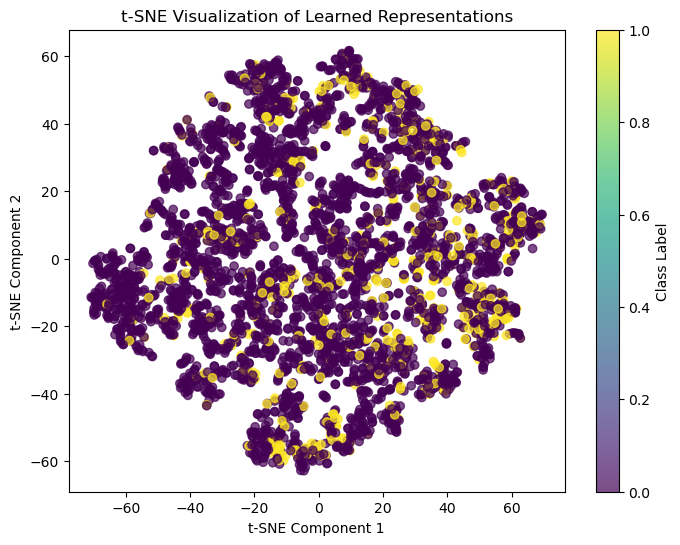

In [176]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Apply t-SNE on the embeddings (2D projection)
tsne = TSNE(n_components=2, random_state=42, verbose=1)
X_train_tsne = tsne.fit_transform(X_train_embeddings)

# Visualize the t-SNE result for the training data
plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(label='Class Label')
plt.title('t-SNE Visualization of Learned Representations')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()


UMAP(n_jobs=1, random_state=42, verbose=1)
Mon Apr  7 22:56:52 2025 Construct fuzzy simplicial set


/Users/tnorlha/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Apr  7 22:56:56 2025 Finding Nearest Neighbors
Mon Apr  7 22:56:57 2025 Finished Nearest Neighbor Search
Mon Apr  7 22:56:57 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon Apr  7 22:57:01 2025 Finished embedding


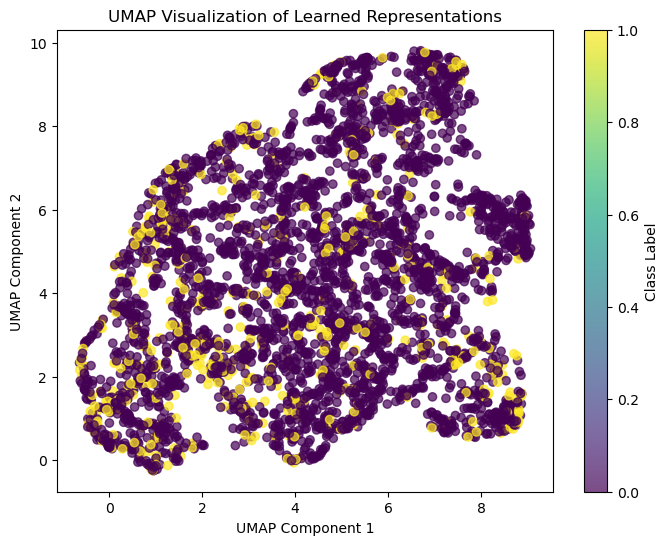

In [177]:
import umap
import matplotlib.pyplot as plt

# Apply UMAP on the embeddings (2D projection)
umap_model = umap.UMAP(n_components=2, random_state=42, verbose=1)
X_train_umap = umap_model.fit_transform(X_train_embeddings)

# Visualize the UMAP result for the training data
plt.figure(figsize=(8, 6))
plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(label='Class Label')
plt.title('UMAP Visualization of Learned Representations')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

In [178]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score for t-SNE
silhouette_tsne = silhouette_score(X_train_tsne, y_train)
print(f"Silhouette Score (t-SNE): {silhouette_tsne:.4f}")

# Calculate silhouette score for UMAP
silhouette_umap = silhouette_score(X_train_umap, y_train)
print(f"Silhouette Score (UMAP): {silhouette_umap:.4f}")

Silhouette Score (t-SNE): 0.0284
Silhouette Score (UMAP): 0.0337
